In [1]:
from IPython.display import Image


<br>

## 1. The Strategy: "Time to Interact" (TTI)
The speaker shares an insight from his time at Facebook: **it’s the latency that drives the experience**, not the total time it takes to complete an operation.
* **The Metric:** Facebook measures "Time to Interact." This is the time from a user's action to the appearance of the first **interactive subset** of the UI. It doesn’t have to be the whole UI—just enough for you to start using it.
* **The Loading Logic:** To minimize this time, the website is split into independent parts. The most fundamental part loads first, while the rest loads in the background. If they tried to render everything perfectly at once, the database queries and data transfer would take so long that you wouldn't see anything for a while.

## 2. The Example: Infinite Scroll & Placeholders
He explains that without background loading, features like **Infinite Scroll** would be "downright impossible."
* **The Placeholder Screenshot:** He intentionally scrolled faster than his network could keep up to show two gray "placeholder" items.
* **The Purpose:** These items are not interactive, but they are great suggestions that "something is coming." This makes the user more likely to wait.
* **Background "Gluing":** Usually, code fetches content and "glues" it to the bottom before you even reach the end. If the background process isn't fast enough, you hit the end and see those placeholders.

<br>

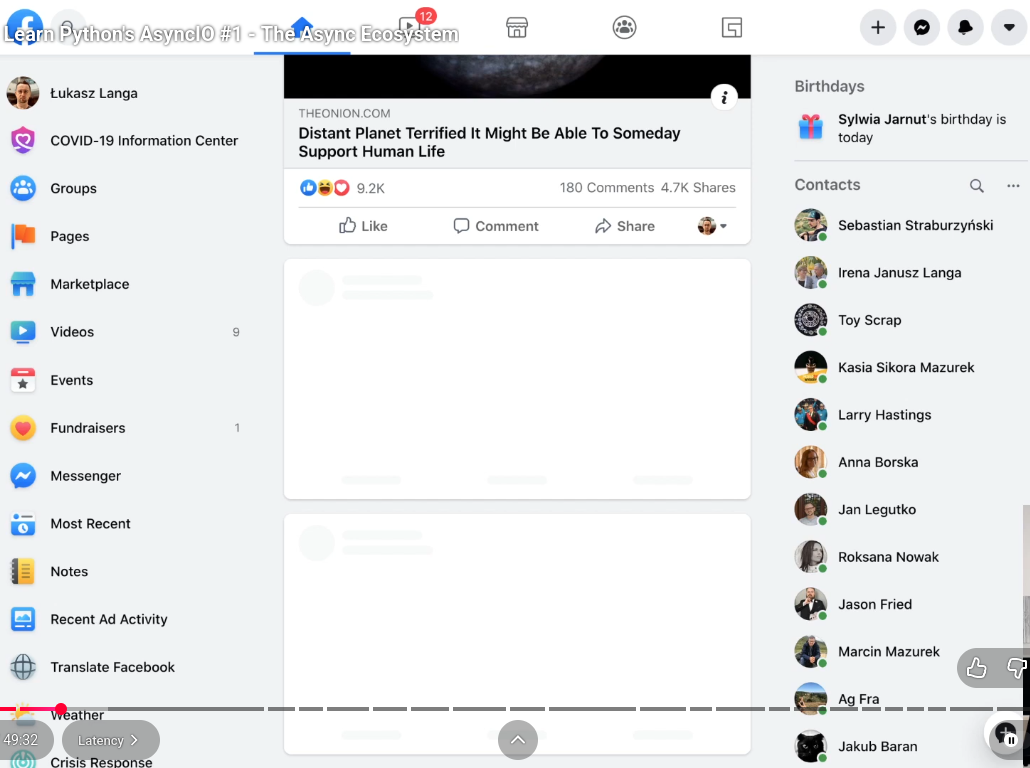

In [4]:
Image("../img/img03.png")

<br>


## 3. The Highway Analogy: Sync vs. Async
This is how he explains the difference between blocking and non-blocking code:
* **Synchronous Execution (The Single Lane):** Imagine a highway lane that is only as fast as the slowest car. If a driver stops to write down an address someone is giving them over the phone, the lane is blocked. It doesn’t matter if you are driving a **supercharged V8 Hellcat**—you have to wait.
* **Asynchronous Execution (Adding Lanes):** To unblock the flow, you add more lanes. These lanes are **Execution Threads**. The original thread is the "Main Thread," and the others are "Secondary" or "Worker" threads.

## 4. The Python Code Example: Threading Dangers
He provides a specific Python example to show why background threads can be dangerous.
* **The Code:** He created a class that inherits from `threading.Thread`. It takes a dictionary (mapping), iterates over it, and "sleeps."
* **The Crash:** While the background thread was iterating over the dictionary, he added a new element to that same dictionary from the Main Thread.
* **The Error:** The program crashed because the dictionary "changed size" during iteration. 
* **Race Conditions:** He warns that sometimes the timing might be different and you won't see an error at all. These are called **Race Conditions**, and they are extremely hard to debug because they are inconsistent.

<br>


### Thread vs. Process:

Think of a **Process** as a house and a **Thread** as a person living inside that house.

| Feature | Thread | Process |
| :--- | :--- | :--- |
| **Memory** | Shares memory with other threads in the same process. | Has its own private memory space. |
| **Speed** | Fast to create and switch between. | Slower to start and "heavyweight." |
| **Isolation** | If one thread crashes, it can crash the whole process. | If one process crashes, others keep running. |
| **Communication** | Easy (they share the same variables). | Hard (requires special "IPC" tools). |

<br>

In [5]:

import time 
import threading
from typing import Mapping

class Mayhem(threading.Thread):
    def __init__(self,map:Mapping[str,int])->None:
        super().__init__()
        self.map_data = map 
    
    def run(self):
        for key,value in self.map_data.items():
            time.sleep(value)

d = {"K1":1,"K2":2,"K3":3}
obj = Mayhem(d)

# secedary thred:(.start())
obj.start()

# add new element to the "Main thred". 
d["k4"] = 10 

# Occur errors cause, main thread iterating values but at the same time another thread insert new vaules
# we got error


Exception in thread Thread-26:
Traceback (most recent call last):
  File "/usr/lib/python3.14/threading.py", line 1082, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "/tmp/ipykernel_2689/2466779974.py", line 11, in run
    for key,value in self.map_data.items():
                     ~~~~~~~~~~~~~~~~~~~^^
RuntimeError: dictionary changed size during iteration


<br>

---

<br>

## 5. The Solution: Locking Mechanisms
To avoid these issues, he introduces **Synchronization Primitives**, specifically the **Lock**.
* **How it Works:** A lock allows one thread to acquire exclusive access to a resource (like the dictionary). Other threads must wait until the lock is released.
* **The Efficiency Problem:** He asks, "Are locks a silver bullet?" and the answer is **no**. 
* **The Performance Cost:** If many threads are competing for the same resource, they spend a lot of time "blocked" (waiting). In his diagram, this is shown as dark areas where the thread is not doing any work. Even if you have 100% CPU usage, the program might not be efficient if threads are constantly waiting on each other.




## 6. Lock Problems: Contention and Starvation

When multiple threads want to use a single resource (like a file or a variable), we use a **lock**. However, this lock itself becomes the root of several problems.

**Lock Contention**
This happens when many threads try to acquire the same lock at the same time.
* **Result:** Instead of doing their actual work (computation), the threads sit idle waiting for the lock. This significantly reduces program performance. In your example of 4 threads, while Thread-1 holds the lock, the other 3 threads sit idle, wasting system resources.


**Lock Starvation**
Locks do not always practice "justice." The Python thread scheduler isn't always fair when deciding which thread gets the lock next.
* **Example:** Thread-3 and Thread-4 have been waiting in line for a long time. However, as soon as the lock is released, Thread-1 (which might have just finished) quickly grabs it again. Consequently, Thread-4 might never get a chance to run. This is called starvation.



## 7. Deadlock (The Ultimate Standstill)

A deadlock is a situation where two or more threads wait for each other indefinitely, causing the program to freeze.

* **Simple Analogy:** You go to a store to buy safety gloves. The store's rule is that you cannot enter without wearing gloves. But you don't have gloves; you are there to buy them. You can't get in because you don't have gloves, and you can't get gloves because you can't get in.
* **In Programming:** Thread-A holds Lock-1 and wants Lock-2. Meanwhile, Thread-B holds Lock-2 and wants Lock-1. Neither will release what they have, so the entire program hangs.



## 8. Python’s Specific Hurdle: The GIL (Global Interpreter Lock)

Why don't we get "true" parallelism even when using threading in Python? The answer is the **GIL**.

* **What is the GIL?** It is a mutex (a lock) that protects the Python interpreter. It ensures that only one thread can execute Python bytecode at any given time.
* **Why does it exist?** Python's memory management (Reference Counting) is not thread-safe. Without the GIL, multiple threads working on memory simultaneously could cause data corruption.
* **The Performance Trick:** As you correctly noted, Larry Hastings' **Gilectomy** project demonstrated that removing the GIL actually made Python slower. Replacing one big lock with thousands of tiny, fine-grained locks created so much management overhead that it slowed down execution.


## 9. Explaining the Facebook Example: "CPU Leak"

The Facebook production example you mentioned is excellent. Here is what happened:

1.  **Three Threads:** Main Thread (Blue), Worker Thread (Green), and a Metrics Thread (used to measure performance).
2.  **The Problem:** The Metrics thread was designed to do some data pre-processing, which started consuming massive amounts of CPU time.
3.  **The GIL Impact:** Since Python can only run one thread at a time, while the Metrics thread was busy doing heavy calculations, it held onto the GIL for long periods.
4.  **The Result:** The Main and Worker threads never got a chance to run. This is what you called a **"CPU Leak"**—there was no traditional memory leak, but the primary threads were starved of "air" (CPU cycles) because of another thread.




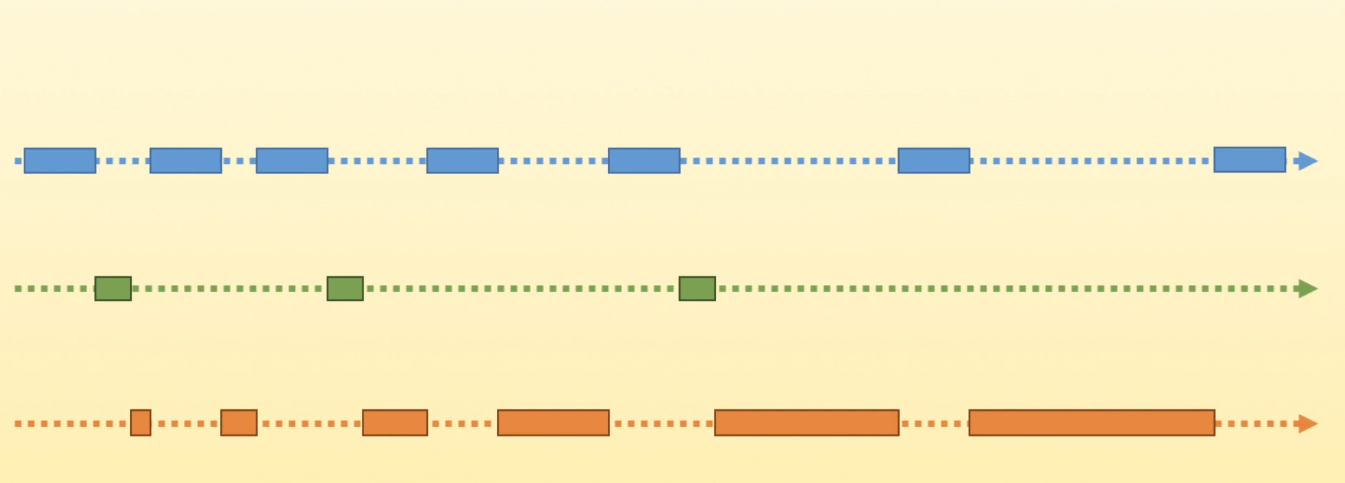

In [6]:
Image("../img/img04.png")

## 10. Thread vs. Process (Key Differences)

| Feature | Thread | Process |
| :--- | :--- | :--- |
| **Memory** | All threads share the same memory space. | Each process has its own private memory. |
| **GIL** | All threads are under a single GIL. | Each process has its own independent GIL. |
| **Performance** | Best for I/O tasks (Network, Files). | Best for heavy math (CPU Bound). |
| **Risk** | One thread's error can crash the whole program. | If one process crashes, others continue running. |
